A notebook for testing with twoOct array with gen 2 readout

March 2026
Ruixuan (Matt) Xie  
MattXie956@gmail.com  

Compatible gateware version:  
gateware_v16p2.xsa

In [1]:
# Checking device temperature
import os

# Base path (adjust device number if needed based on 'ls /sys/bus/iio/devices')
base_path = '/sys/bus/iio/devices/iio:device0'

def read_temp(channel_prefix):
    raw_path = os.path.join(base_path, f'{channel_prefix}_raw')
    offset_path = os.path.join(base_path, f'{channel_prefix}_offset')
    scale_path = os.path.join(base_path, f'{channel_prefix}_scale')
    
    with open(raw_path, 'r') as f:
        raw = float(f.read().strip())
    with open(offset_path, 'r') as f:
        offset = float(f.read().strip())
    with open(scale_path, 'r') as f:
        scale = float(f.read().strip())
    
    temp_c = ((raw + offset) * scale) / 1000.0
    return temp_c

# PS temperature
ps_temp = read_temp('in_temp0_ps_temp')
print(f"PS Temperature: {ps_temp:.2f} °C")

# PL temperature
pl_temp = read_temp('in_temp2_pl_temp')
print(f"PL Temperature: {pl_temp:.2f} °C")

PS Temperature: 50.47 °C
PL Temperature: 53.98 °C


from docs, Recommended Maximum Operating Junction Temperature (Commercial Grade): 100°C. Operation above 100°C is possible for a limited time. Operating Ambient Temperature Range (Board Level): 0°C to +45°C

# Imports

In [2]:
%matplotlib notebook

from pynq import Overlay
from pynq import MMIO
import xrfclk
import xrfdc
import numpy as np
from matplotlib import pyplot as plt
import time
import os

from src import analysis

# Gateware upload

In [3]:
# FIRMWARE UPLOAD
gateware = Overlay("gateware/gateware_v16p2.xsa",ignore_version=True)  #

# INITIALIZING PLLs
clksrc = 409.6 # MHz
xrfclk.set_all_ref_clks(clksrc)

# Constants

In [4]:
cut = 1 # chan under test

fs = 1.024e9
parallel_factor = 4
psb_channel_count = 2048
lut_len = 2**21
accum_length = 1024
snapBinLength = 256

SWEEP_STEPS = 1000 # number of sweep steps
TARGET_CHAN_BW = 1 # target sweep channel bandwidth [MHz]

# Gateware functions (in use)

In [5]:
# ---------------functions that involve overlay-----------------------------
def _gateware_chan(gateware, chan):
    """
    Returns the handle to the specified readout channel in the overlay gateware.

    Args:
        gateware (pynq.overlay.Overlay): 
            The uploaded overlay object.
        chan (int): 
            Channel index (1–4) specifying which readout chain to access.

    Returns:
        pynq.overlay.DocumentHierarchy: 
            The gateware channel object corresponding to the requested channel.

    """
    return {
        1: gateware.chan1,
        2: gateware.chan2,
        3: gateware.chan3,
        4: gateware.chan4,
    }[chan]


def startReadout(chan):
    '''
    Starts a readout chain.
    
    Args:
        chan (int): 
            Channel index (1–4) specifying which readout chain to access.
            
    Notes: 
        In the 4 chain design, starting chan1 will start all chans.
    '''
    chan_access = _gateware_chan(gateware, chan)
    
    chan_access.GPIO.axi_gpio_0.write(0x0,0)
    chan_access.GPIO.axi_gpio_0.write(0x0,1)
    
    
def _setNCLO(chan, lofreq, ASU=False):

    # lofreq *= freqOffsetFixHackFactor() # Fequency offset fix
    # implemented in tones._writeComb and alcove_base._setNCLO

    # import xrfdc
    rf_data_conv = gateware.usp_rf_data_converter_0
    
    if ASU:
        tb_indices = {
            1: [1,0,1,3], 2: [1,1,1,2], 3: [0,1,1,0], 4: [0,0,1,1]}
    else:
        tb_indices = {
            1: [0,0,1,3], 2: [0,1,1,2], 3: [1,0,1,1], 4: [1,1,1,0]}

    ii = tb_indices[chan]
    adc = rf_data_conv.adc_tiles[ii[0]].blocks[ii[1]]
    dac = rf_data_conv.dac_tiles[ii[2]].blocks[ii[3]]

    adc.MixerSettings['Freq'] = -lofreq
    dac.MixerSettings['Freq'] = lofreq
    adc.UpdateEvent(xrfdc.EVENT_MIXER)
    dac.UpdateEvent(xrfdc.EVENT_MIXER)
    
    path = "twoOctaveReadout_files"
    os.makedirs(path, exist_ok=True)
    np.save(os.path.join(path, f"f_center_vna_{chan}.npy"), lofreq*1e6)
    
    
def setFFTscale(chan, SI_tx=2016, SI_rx=2016):
    '''
    Sets the internal scaling of the FFT module.
    
    Args: 
        chan (int): 
            Channel index (1–4) specifying which readout chain to access.
        scale (ufix_11):
            Each HIGH bit enables a shift to the right at a FFT stage.
            
    Notes: 
        SI_tx for PSB, SI_rx for receive
    '''
    chan_access = _gateware_chan(gateware, chan)
    
    gpio_4_slot_2_word = int(SI_tx<<11 | SI_rx)
    chan_access.GPIO.axi_gpio_4.write(0x08,gpio_4_slot_2_word)
    path = "twoOctaveReadout_files"
    np.save(os.path.join(path, f"IFFT_scale_{chan}.npy"), SI_tx)
    np.save(os.path.join(path, f"FFT_scale_{chan}.npy"), SI_rx)
    
    
def setAccumLenAndSnapBinLen(chan, acc_factor, bin_len):
    '''
    Sets the accumulation factor (averaging length) in the receive DSP, which will impact output rate.
    Modifies the data structure returned by getSnapData(*, mux_sel=3).
    
    Args:
        chan (int): 
            Channel index (1–4) specifying which readout chain to access.
        acc_factor (int): 
            The accumulation length of receive outputs (the length of avg filter).
        bin_len (int): 
            Determines the number of clk cycles to be captured by getSnapData(mux_sel=3), accepts value in [5,512].
                Example: 
                    Capture all 2048 bins if set to 512,
                    1024 bins if set to 256.
                       
    Notes:
        parallel_factor=4 and psb_channel_count=2048 are specific to gateware, not arbitrary,
        these values probably should be in a config file
    '''
    chan_access = _gateware_chan(gateware, chan)
    
    acc_length = int(psb_channel_count/parallel_factor * acc_factor - 4)
    getAccumChan = int(bin_len - 3)
    
    chan_access.GPIO.axi_gpio_3.write(0x00, getAccumChan * 2**23 + acc_length)
    
    
def setPSBscaleConst(chan, C=2**15):
    '''
    Scales the magnitude of the waveform at the output of PSB, by C/2^15.
    
    Args: 
        chan (int): 
            Channel index (1–4) specifying which readout chain to access.
        C (ufix_29):
            Output magnitude = input magnitude * C / 2^15.
    Return:
        ov_flag (bin)
            
    Notes: This is intended for scaling the PSB outputs to the DAC maximum range. It can cause overflow (saturation)
          if C is too large.
    '''
    gwc = _gateware_chan(gateware, chan)
    
    gwc.GPIO.axi_gpio_5.write(0x00, int(0b111<<29 | int(C)))
    gwc.GPIO.axi_gpio_5.write(0x00, int(C))
    ov_flag = gwc.GPIO.axi_gpio_5.read(0x08)
    subsystems = ["psb-ifft", "psb-overlap-add", "psb-post-scale"]

    ov_status = {
        name: bool(ov_flag & (1 << i))
        for i, name in enumerate(subsystems)
    }
    
    path = "twoOctaveReadout_files"
    np.save(os.path.join(path, f"PSB_scale_{chan}.npy"), C)
    
    return ov_status


def clearAllTones():
    '''
    Writes zeros to all tone parameters in all 4 chans.
            
    Notes: To keep a tone going while suppressing it's power,
          simply write 0 amp to it while keeping dphi and init vector
          There's another option to suppress tones in toneSelect
    '''
    
    gateware_chans = [gateware.chan1, gateware.chan2, gateware.chan3, gateware.chan4]
    for gwc in gateware_chans:
        gwc.GPIO.axi_gpio_2.write(0x00, 0)
        gwc.GPIO.axi_gpio_2.write(0x08, 0)
        for addr in range(256):
            gwc.GPIO.axi_gpio_1.write(0x08, int(addr << 16))
            gwc.GPIO.axi_gpio_1.write(0x00, 0xff)
            gwc.GPIO.axi_gpio_1.write(0x00, 0)


def clearChanTones(chan):
    '''
    Writes zeros to all tone parameters in one of the chans.
    
    Args:
        chan (int): 
            Channel index (1–4) specifying which readout chain to access.
            
    Notes: To keep a tone going while suppressing it's power,
          simply write 0 amp to it while keeping dphi and init vector
          There's another option to suppress tones in toneSelect
    '''
    
    gwc = _gateware_chan(gateware, chan)
    gwc.GPIO.axi_gpio_2.write(0x00, 0)
    gwc.GPIO.axi_gpio_2.write(0x08, 0)
    for addr in range(256):
        gwc.GPIO.axi_gpio_1.write(0x08, int(addr << 16))
        gwc.GPIO.axi_gpio_1.write(0x00, 0xff)
        gwc.GPIO.axi_gpio_1.write(0x00, 0)


def _writeTone_james(chan, mem, addr, dphi, init_re, init_im):
    """
    Writes one tone defined by its frequency (dphi) and initial vector (init_re, init_im).
    """

    if not (0 <= mem <= 7):
        return

    chan_access = _gateware_chan(gateware, chan)

    chan_access.GPIO.axi_gpio_2.write(0x00, int(round(init_re*(1 << 16))) & 0x3FFFF)
    chan_access.GPIO.axi_gpio_2.write(0x08, int(round(init_im*(1 << 16))) & 0x3FFFF)

    if mem & 1:  # mem odd: add π
        dphi = _wrap_angle(dphi + np.pi)
    dphi_int, _ = _rad2int(dphi)

    word = int((addr << 16) + dphi_int)
    bit_value = [1,16,2,32,4,64,8,128][mem]
    
    chan_access.GPIO.axi_gpio_1.write(0x08, word)
    chan_access.GPIO.axi_gpio_1.write(0x00, bit_value)
    chan_access.GPIO.axi_gpio_1.write(0x00, 0)
    
    
def _loadAllTones(chan, bin_num, dphi, init_re, init_im):
    '''
    Writes all tones listed in 1darrays
    
    Args:
        chan (int): 
            Channel index (1–4) specifying which readout chain to access.
        bin_num (int);
            The FFT bin number of which the tone is in.
        dphi (float): 
            The step in phase which defines the frequency of the tone from bin center.
            Note: In unit [rad]
        init_re (float),
        init_im (float): 
            The real and imarinary parts of the initial vector.
            Note: The maximum magnitude of the initial vector is 1.
    
    '''
    for i in range(bin_num.size):
        _writeTone_james(chan, bin_num[i]%8, bin_num[i]//8, dphi[i], init_re[i], init_im[i])


def _writeToneSelect(chan, addr, data):
    '''
    Updates toneSelect parameter memory at one address
    
    Args:
        chan (int): 
            Channel index (1–4) specifying which readout chain to access.
        addr (uint): 
            The address of the write operation.
        data (ufix_12):
            The data of the write operation.
    '''
    chan_access = _gateware_chan(gateware, chan)
    
    gpio_6_slot_2_word = int(addr)
    chan_access.GPIO.axi_gpio_6.write(0x08,gpio_6_slot_2_word)
    
    gpio_7_slot_1_word = int((data[1] << 12) + data[0])
    chan_access.GPIO.axi_gpio_7.write(0x00,gpio_7_slot_1_word)
    gpio_7_slot_2_word = int((data[3] << 12) + data[2])
    chan_access.GPIO.axi_gpio_7.write(0x08,gpio_7_slot_2_word)
    gpio_8_slot_1_word = int((data[5] << 12) + data[4])
    chan_access.GPIO.axi_gpio_8.write(0x00,gpio_8_slot_1_word)
    gpio_8_slot_2_word = int((data[7] << 12) + data[6])
    chan_access.GPIO.axi_gpio_8.write(0x08,gpio_8_slot_2_word)
    
    chan_access.GPIO.axi_gpio_6.write(0x00,1)
    chan_access.GPIO.axi_gpio_6.write(0x00,0)
    
    
def _writeToneSelectAll(chan, ToneSelMap):
    '''
    Updates the entire toneSelect LUT from ToneSelMap
    
    Args:
        chan (int): 
            Channel index (1–4) specifying which readout chain to access.
        ToneSelMap (numpy.ndarray):
            The toneSelect LUT.
    '''
    for i in range(256):
        _writeToneSelect(chan, i, ToneSelMap[i])
        

def _updateToneSelMap(chan, toneSelectInfo, turn_off_unused_bin=True):
    '''
    It updates the init toneSelMap base on the toneSelectInfo.
    Used in case of 2 tones per bin. 
    
    Args:
        chan (int): 
            Channel index (1–4) specifying which readout chain to access.
        toneSelectInfo (numpy.ndarray):
            An array with bin reuse mapping information.
        turn_off_unused_bin (bool):
            True: remove the duplicate tone from bin reuse mechanism.
    '''
    toneSelectMap = genInitToneSelMap()
    for value in toneSelectInfo.T:
        twoTone_bin, unused_bin = value
        temp = toneSelectMap[unused_bin//8, unused_bin%8]
        toneSelectMap[twoTone_bin//8, twoTone_bin%8] = temp
        if turn_off_unused_bin:
            toneSelectMap[unused_bin//8, unused_bin%8] = 0
    _writeToneSelectAll(chan, toneSelectMap)
    
    
def _writeBinMap(chan, addr, data):
    '''
    Write to gateware registers via GPIO.
    Updates the bin select mapping (LUT) in the receive.
    
    Args:
        chan (int): 
            Channel index (1–4) specifying which readout chain to access.
        addr (uint): 
            The address of the write operation.
        data (ufix_22):
            The data of the write operation.
            
    Notes:
        The bin map RAM are accecced 2 addrs at a time, 
        only the first addr need to be supplied, each addr take two values
        each 11 bits concatenated.
        For example, if addr=n, then 
        concact(data[1],data[0])LSB -> addr n
        concact(data[3],data[2])LSB -> addr n+1
    '''
    chan_access = _gateware_chan(gateware, chan)
    
    gpio_9_slot_1_word = int((data[1]<<21) + (data[0]<<10) + addr)
    chan_access.GPIO.axi_gpio_9.write(0x00, gpio_9_slot_1_word)
    gpio_9_slot_2_word = int((data[3]<<12) + (data[2]<<1) + 0)
    chan_access.GPIO.axi_gpio_9.write(0x08, gpio_9_slot_2_word)
    
    gpio_9_slot_2_word = int((data[3]<<12) + (data[2]<<1) + 1)
    chan_access.GPIO.axi_gpio_9.write(0x08, gpio_9_slot_2_word)
    gpio_9_slot_2_word = int((data[3]<<12) + (data[2]<<1) + 0)
    chan_access.GPIO.axi_gpio_9.write(0x08, gpio_9_slot_2_word)
    
    
def _loadBinMap(chan, bin_map):
    '''
    Updates the bin select mapping (LUT) in the receive.
    
    Args:
        chan (int): 
            Channel index (1–4) specifying which readout chain to access.
        bin_map (numpy.ndarray):
            Array of bin select mapping LUT.
    '''
    bin_map_reshape = bin_map.reshape((512, 4))
    for i in range(512):
        _writeBinMap(chan, 2*i, bin_map_reshape[i])
        
        
def _writeBeatDphi(chan, mem, addr, beatDphi):
    '''
    Write to gateware registers via GPIO.
    Updates the beat frequencies corresponding to each tone, 
    for the digital down conversion (DDC) in receive.
    
    Args:
        chan (int): 
            Channel index (1–4) specifying which readout chain to access.
        mem (int {0,1,2,3}):
            An index that maps to one of the 4 BRAMs on 4 parallel paths.
        addr (uint): 
            The address of the write operation.
        beatDphi (float):
            The step in phase that defines the beat frequency, in unit [rad].     
    '''
    chan_access = _gateware_chan(gateware, chan)
    
    beatDphi_write,_ = _rad2int(beatDphi)
    gpio_4_slot_1_word = int((addr << 20) + (beatDphi_write << 4))
    
    chan_access.GPIO.axi_gpio_4.write(0x00,gpio_4_slot_1_word)
    if mem == 0:
        chan_access.GPIO.axi_gpio_4.write(0x00,gpio_4_slot_1_word + 2**0)
        chan_access.GPIO.axi_gpio_4.write(0x00,gpio_4_slot_1_word)
    elif mem == 1:
        chan_access.GPIO.axi_gpio_4.write(0x00,gpio_4_slot_1_word + 2**1)
        chan_access.GPIO.axi_gpio_4.write(0x00,gpio_4_slot_1_word)
    elif mem == 2:
        chan_access.GPIO.axi_gpio_4.write(0x00,gpio_4_slot_1_word + 2**2)
        chan_access.GPIO.axi_gpio_4.write(0x00,gpio_4_slot_1_word)
    elif mem == 3:
        chan_access.GPIO.axi_gpio_4.write(0x00,gpio_4_slot_1_word + 2**3)
        chan_access.GPIO.axi_gpio_4.write(0x00,gpio_4_slot_1_word)
        
        
def _loadBeatDphiMap(chan, beat_dphi_map):
    '''
    Updates the beat frequencies corresponding to each tone, 
    for the digital down conversion (DDC) in receive.
    
    Args:
        chan (int): 
            Channel index (1–4) specifying which readout chain to access.
        beat_dphi_map (numpy.ndarray):
            beat dphi LUT values.
    '''
    beat_dphi_map_reshape = beat_dphi_map.reshape((512, 4))
    for addr in range(512):
        for mem in range(4):
            _writeBeatDphi(chan, mem, addr, beat_dphi_map_reshape[addr, mem])


def writeComb(chan, freqs, amps, phis):
    '''
    Writes a comb of frequencies from user specified frequencies, amplitudes (magnitudes) and phases.
    
    Args:
        chan (int): 
            Channel index (1–4) specifying which readout chain to access.
        freqs(numpy.1darray):
            A list of frequencies, within 1GHz bandwidth, centered at DC.
        amps (numpy.1darray):
            The normalized magnitude of each frequency, maximum = 1.0.
        phis (numpy.1darray):
            The phases of each frequency, in [rad].
    Returns:
        freqs_actual (numpy.1darray)
        bin_map (numpy.1darray)
        transmit_bin_count (int)
        secondTone_flag (bool)
        
    Notes:
        Generate optimal phases with genBestPhis() and always clearAllTones() before writing new combs.
    '''

    init_re, init_im = _phase2vector(phis, amps)
    
    f_step = fs/lut_len
    freqs_actual = np.round(freqs / f_step) * f_step
    
    bin_num = np.round(freqs_actual/(fs/psb_channel_count)).astype(np.int64)
    
    # dphi/2pi ratio corresponds to the channel bandwidth of PSB which is 2*fs/2048
    dphi = _wrap_angle(np.pi*(freqs_actual/(fs/psb_channel_count) - bin_num))
    beat_dphi = _wrap_angle(-2*dphi)  # Careful with different sampling frequency
    
    # Represent bin numbers with all positive values
    temp = bin_num < 0
    bin_num[temp] += 2048
    
    bin_count = np.bincount(bin_num, minlength=2048)
    
    bin_map = np.zeros(2048, dtype=int)
    beat_dphi_map = np.zeros(2048, dtype=float)
    beat_dphi_2048 = np.zeros(2048, dtype=float)
    
    # For any two tones per bin instances, the second bin index will be replaced
    # with an unused bin index, and this mapping is saved in toneSelectInfo
    second_tone_index = _find_second_instance_indices(bin_num)
    if second_tone_index.size > 0:
        secondTone_flag = True
        
        all_bins = np.arange(2048)
        unused_bins = np.setdiff1d(all_bins, bin_num)
        unused_bins = unused_bins[unused_bins != 0]  # Remove 0 if present
        
        # bins to be replaced (second instances)
        orig_bins = bin_num[second_tone_index]

        # split unused bins by parity
        unused_even_bins = unused_bins[(unused_bins & 1) == 0]
        unused_odd_bins  = unused_bins[(unused_bins & 1) == 1]

        # parity requirement of replacements
        needs_even = (orig_bins & 1) == 0

        # build replacement bins aligned with second_tone_index
        replacement_bins = np.empty_like(orig_bins)
        replacement_bins[needs_even]  = unused_even_bins[:needs_even.sum()]
        replacement_bins[~needs_even] = unused_odd_bins[:(~needs_even).sum()]

        # replace ONLY the second instances
        bin_num[second_tone_index] = replacement_bins

        # record before/after mapping
        toneSelectInfo = np.vstack((orig_bins, replacement_bins))

        _updateToneSelMap(chan, toneSelectInfo)
        
        beat_dphi_2048[bin_num] = beat_dphi
        temp = beat_dphi_2048[toneSelectInfo[1]]
        beat_dphi_2048[toneSelectInfo[1]] = 0
        beat_dphi_2048_stack = np.vstack([beat_dphi_2048,beat_dphi_2048])
        beat_dphi_2048_stack[1, toneSelectInfo[0]] = temp

        transmit_bin_count = 0
        for i in range(2048):
            if bin_count[i] == 2:
                bin_map[transmit_bin_count] = i
                beat_dphi_map[transmit_bin_count] = beat_dphi_2048_stack[0, i]
                transmit_bin_count += 1
                bin_map[transmit_bin_count] = i
                beat_dphi_map[transmit_bin_count] = beat_dphi_2048_stack[1, i]
                transmit_bin_count += 1
            elif bin_count[i] == 1:
                bin_map[transmit_bin_count] = i
                beat_dphi_map[transmit_bin_count] = beat_dphi_2048_stack[0, i]
                transmit_bin_count += 1
    else:
        secondTone_flag = False
        _writeToneSelectAll(chan, genInitToneSelMap())
        
        beat_dphi_2048[bin_num] = beat_dphi
        transmit_bin_count = 0
        for i in range(2048):
            if bin_count[i] == 1:
                bin_map[transmit_bin_count] = i
                beat_dphi_map[transmit_bin_count] = beat_dphi_2048[i]
                transmit_bin_count += 1

    _loadBinMap(chan, bin_map)
    _loadBeatDphiMap(chan, beat_dphi_map)
    
    _loadAllTones(chan, bin_num, dphi, init_re, init_im)
    
    writeChannelCount(chan, transmit_bin_count)
    
    path = "twoOctaveReadout_files"
    os.makedirs(path, exist_ok=True)

    f_center = np.load(os.path.join(path, f"f_center_vna_{chan}.npy"))
    freqs_rf_actual = freqs_actual + f_center
    np.save(os.path.join(path, f"f_rf_tones_comb_{chan}.npy"), freqs_rf_actual)
    np.save(os.path.join(path, f"a_tones_comb_{chan}.npy"), amps)
    np.save(os.path.join(path, f"p_tones_comb_{chan}.npy"), phis)

    np.save(os.path.join(path, f"bin_map_tones_comb_{chan}.npy"), bin_map)
    np.save(os.path.join(path, f"beat_dphi_map_tones_comb_{chan}.npy"), beat_dphi_map)
    
    return freqs_actual


def getSnapData(chan, mux_sel, wait=0.02):
    '''
    Fetch data from gateware DSP.
    
    Args:
        chan (int): 
            Channel index (1–4) specifying which readout chain to access.
        mux_sel:
            0: ADC outputs
            1: PSB outputs (DAC inputs)
            3: Receive outputs (time stream data)
    Returns:
        I, Q (numpy.ndarray):
            for data converter data, I and q are flat,
            for time stream data, I and Q have shape (n, bin)
    '''
    import numpy as np
    import time
    from pynq import MMIO
    
    # reset snap
    access = _gateware_chan(gateware, chan).GPIO.axi_gpio_3
    access.write(0x08, 3)
    access.write(0x08, 0)
    time.sleep(wait)
    
    match chan:
        case 1:
            match mux_sel:
                case 0 | 1:
                    base_addr_wide  = 0x00_A001_0000
                case 3:
                    base_addr_wide  = 0x00_A002_0000
        case 2:
            match mux_sel:
                case 0 | 1:
                    base_addr_wide  = 0x00_A003_0000
                case 3:
                    base_addr_wide  = 0x00_A004_0000
        case 3:
            match mux_sel:
                case 0 | 1:
                    base_addr_wide  = 0x00_A005_0000
                case 3:
                    base_addr_wide  = 0x00_A006_0000
        case 4:
            match mux_sel:
                case 0 | 1:
                    base_addr_wide  = 0x00_A007_0000
                case 3:
                    base_addr_wide  = 0x00_A008_0000
                    
    max_count = 65536  # 32x2048 = 65536
    mmio_wide_bram = MMIO(base_addr_wide , max_count)
    wide_data = mmio_wide_bram.array[0:16384]  # max/4, bram depth*word_bits/32bits
    
    I = np.zeros(8192)
    Q = np.zeros(8192)
    
    match mux_sel:
        case 0 | 1:
            up_PSB_q0, lw_PSB_i0 = np.int16(wide_data[0::8] >> 16), np.int16(wide_data[0::8] & 0x0000ffff)
            up_PSB_q1, lw_PSB_i1 = np.int16(wide_data[1::8] >> 16), np.int16(wide_data[1::8] & 0x0000ffff)
            up_PSB_q2, lw_PSB_i2 = np.int16(wide_data[2::8] >> 16), np.int16(wide_data[2::8] & 0x0000ffff)
            up_PSB_q3, lw_PSB_i3 = np.int16(wide_data[3::8] >> 16), np.int16(wide_data[3::8] & 0x0000ffff)
            up_ADC_i1, lw_ADC_i0 = np.int16(wide_data[4::8] >> 16), np.int16(wide_data[4::8] & 0x0000ffff)
            up_ADC_i3, lw_ADC_i2 = np.int16(wide_data[5::8] >> 16), np.int16(wide_data[5::8] & 0x0000ffff)
            up_ADC_q1, lw_ADC_q0 = np.int16(wide_data[6::8] >> 16), np.int16(wide_data[6::8] & 0x0000ffff)
            up_ADC_q3, lw_ADC_q2 = np.int16(wide_data[7::8] >> 16), np.int16(wide_data[7::8] & 0x0000ffff)
            
            if mux_sel == 0:
                I[0::4] = lw_ADC_i0
                I[1::4] = up_ADC_i1
                I[2::4] = lw_ADC_i2
                I[3::4] = up_ADC_i3
                Q[0::4] = lw_ADC_q0
                Q[1::4] = up_ADC_q1
                Q[2::4] = lw_ADC_q2
                Q[3::4] = up_ADC_q3
            elif mux_sel == 1:
                I[0::4] = lw_PSB_i0
                I[1::4] = lw_PSB_i1
                I[2::4] = lw_PSB_i2
                I[3::4] = lw_PSB_i3
                Q[0::4] = up_PSB_q0
                Q[1::4] = up_PSB_q1
                Q[2::4] = up_PSB_q2
                Q[3::4] = up_PSB_q3
        case 3:
            i0 = (np.int32(wide_data[0::8])).astype("float")
            q0 = (np.int32(wide_data[1::8])).astype("float")
            i1 = (np.int32(wide_data[2::8])).astype("float")
            q1 = (np.int32(wide_data[3::8])).astype("float")
            i2 = (np.int32(wide_data[4::8])).astype("float")
            q2 = (np.int32(wide_data[5::8])).astype("float")
            i3 = (np.int32(wide_data[6::8])).astype("float")
            q3 = (np.int32(wide_data[7::8])).astype("float")
            
            I[0::4] = i0
            I[1::4] = i1
            I[2::4] = i2
            I[3::4] = i3
            Q[0::4] = q0
            Q[1::4] = q1
            Q[2::4] = q2
            Q[3::4] = q3
            
#             I /= 2**14
#             Q /= 2**14
    return I, Q


def set_fine_nco_frequency(chan, freq_mhz):
    """
    Set the fine NCO (Numerically Controlled Oscillator) frequency.
    
    Args:
        chan (int): 
            Channel index (1–4) specifying which readout chain to access.
        freq_mhz (float);
            Frequency in MHz.
    """

    import numpy as np

    try:
        # Constants
        fs_hz = 1.024e9                    # System sample rate (Hz); 512e6 Hz
        nco_bits = 22                      # Width of NCO phase accumulator
        freq_resolution_hz = fs_hz / 2**nco_bits  # Frequency step per integer DTW

        # Convert desired frequency (MHz) to Hz
        freq_hz = freq_mhz * 1e6

        # Compute digital tuning word (DTW)
        dtw = int(np.round(freq_hz / freq_resolution_hz))

        # Actual frequency that will be set
        actual_freq_hz = dtw * freq_resolution_hz

        # Write DTW to gateware register for the given channel
        chan_access = _gateware_chan(gateware, chan)
        chan_access.GPIO.axi_gpio_10.write(0x00,dtw)
        
        return dtw

    except Exception as e:
        print(f"set_fine_nco_frequency Error: {e}")
        
        
def _sweep(chan, f_center, freqs, N_steps, chan_bandwidth=None, N_accums=8, wait1=0.003, wait2=0.02, cal=True):
    """
    Perform a stepped LO frequency sweep with existing comb centered at f_center.
    
    INPUTS
    f_center:        (float) Center LO frequency for sweep [MHz].
    freqs:           (1D array of floats) Comb frequencies [Hz].
    N_steps:         (int) Number of LO frequencies to divide each channel into.
    chan_bandwidth:  (float) Bandwidth of each channel [MHz].
    
    RETURN: tuple(f, S21)
    f:               (1D array of floats) Central frequency for each bin.
    Z:               (1D array of complex) S_21 complex I+jQ for each bin.
    """

    import numpy as np
    from time import sleep
    import time

    N_steps  = max(1, int(N_steps)) # minimum 1 step
    f_center = float(f_center)
    N_accums = int(N_accums)

    # sort ascending and remove exact duplicates
    # for example:
        # target find resonators uses min in tone channel
        # so two resonators in same tone channel will lead to duplicates
    freqs = np.unique(freqs)
    test = np.sum(freqs >= 0)
    
    # build LO steps
    if chan_bandwidth: # LO bandwidth given
        bw = float(chan_bandwidth) # MHz
    else:              # use tone difference
        bw = np.diff(freqs)[0]/1e6 # MHz
    flos = np.linspace(f_center-bw/2., f_center+bw/2., N_steps, endpoint=False)

    def _Z(lofreq, Naccums=N_accums):
        set_fine_nco_frequency(chan, lofreq)
        time.sleep(wait1) # 0.003 s optimum to settle freq from testing
        Is, Qs = getSnapData(chan, 3, wait2)
        data = (Is + 1.j * Qs)  # convert I and Q to complex
        data = data.reshape((-1, 1024))
        if cal:
            path = "twoOctaveReadout_files"
            beat_dphi_map = np.load(os.path.join(path, f"beat_dphi_map_tones_comb_{cut}.npy"))
            LUT_x, LUT_y = get_FFT_correction()
            FFT_correction = np.interp(beat_dphi_map, LUT_x, LUT_y)[0:1024]
            data *= FFT_correction
        Z = np.mean(data, axis=0)
        Z = np.concatenate((Z[test:len(freqs)], Z[0:test]))
        return Z[0:len(freqs)] # only return relevant slice
    
    start_time = time.time()

    # loop over each LO freq and flatten Z and f
    Z = (np.array([_Z(lofreq-f_center) for lofreq in flos]).T).flatten()
    f = np.array([flos*1e6 + ftone for ftone in freqs]).flatten()

    print(f"_sweep time: {time.time() - start_time}")
        
    set_fine_nco_frequency(chan, 0) # reset LO

    return (f, Z)


def timestreamOn(chan, on=True):
    '''Turn the UDP timestream on (or off) for the current drone.'''

    # input parameter casting
    on = str(on) in {True, 1, '1', 'True', 'true'}

#     udp_control = cfg_b.gateware.gpio_udp_info_control
    udp_control = gateware.udp_control.gpio_udp_info_control
    
#     # current drone channel
#     chan = cfg_b.drid

    # bit values for this drone (01 for on, 10 for off)
    val = 0b01 if on else 0b10

    # construct the 8-bit register value with all zeros except for this drone
    reg_value = val << ((chan - 1) * 2)

    # Write the new register value
    udp_control.write(0x00, reg_value)


def userPacketInfo(chan, data):
    '''Write 16 bits of data to include in the UDP timestream packet.
    Data is drone specific.

    data: 16 bit int to write.8212+42
        Note that Redis will convert user input to string.
        e.g. 255 can be sent as:
            '255', '255.0', '0xFF', '0b11111111', '0o377'
        If conversion fails, then will write 0 instead.
    '''

    # input parameter casting
    data = safe_cast_to_int(data) # returns None if fails
    data = 0 if data is None else data # fails to 0
    data = data & 0xFFFF # ensure data is 16 bits

#     udp_control = cfg_b.gateware.gpio_udp_info_control
    udp_control = gateware.udp_control.gpio_udp_info_control

#     # current drone channel
#     chan = cfg_b.drid

    drone_shift = 16 # Shift for drone ID
    edge_trigger = 19 # Shift for edge-triggered write

    val = ((chan-1)<<drone_shift) | data

    # Write to tmp reg then trigger write to final reg
    udp_control.write(0x08, val)
    udp_control.write(0x08, (1<<edge_trigger) | val)  # edge trigger
    udp_control.write(0x08, val)


def writeChannelCount(chan, num_chans):
    '''Write the number of channels to include in the UDP timestream packet.
    Drone specific.

    num_chans: (int) 16 bits, number of channels.
    '''

    # input parameter casting
    num_chans = safe_cast_to_int(num_chans) # returns None if fails
    num_chans = 0 if num_chans is None else num_chans # fails to 0
    num_chans = num_chans & 0xFFFF # ensure data is 16 bits

#     udp_control = cfg_b.gateware.gpio_udp_info_control
    udp_control = gateware.udp_control.gpio_udp_info_control

#     # current drone channel
#     chan = cfg_b.drid

    count_shift = 18 # Shift for count enable (as opposed to data)
    drone_shift = 16 # Shift for drone ID
    edge_trigger = 19 # Shift for edge-triggered write

    val = (1<<count_shift) | ((chan-1)<<drone_shift) | num_chans

    # Write to tmp reg then trigger write to final reg
    udp_control.write(0x08, val)
    udp_control.write(0x08, (1<<edge_trigger) | val)  # edge trigger
    udp_control.write(0x08, val)


# ===================================functions that don't involve overlay====================================================
def get_FFT_correction():
    fs_in = 1.024e9         # Input sampling rate: 1.024 GHz
    Nfft = 2048             # FFT size
    fs_channel = fs_in / Nfft   # Channel bandwidth: 500 kHz
    accum_length = 1024     # Length of accumulator (moving average filter)
    fs_out = fs_channel / accum_length   # Output sampling rate after decimation (~488.28125 Hz)

    f = np.linspace(-512*fs_out, 511*fs_out, 1024)
    phi = 2*np.pi * f/fs_channel
    H_fft = np.sinc(f/fs_channel)
    H_fft_inv = 1/H_fft
    H_fft_inv_norm = H_fft_inv / H_fft_inv[0]
    
    return phi, H_fft_inv_norm


def compute_crest_factor(signal):
    peak_value = np.max(np.abs(signal))
    rms_value = np.sqrt(np.mean(np.abs(signal) ** 2))
    crest_factor = 20 * np.log10(peak_value / rms_value)
    return crest_factor


def safe_cast_to_int(data_str):
    try:
        if isinstance(data_str, str):
            if data_str.lower().startswith('0x'):   # hex
                return int(data_str, 16)
            elif data_str.lower().startswith('0b'): # bin
                return int(data_str, 2)
            elif data_str.lower().startswith('0o'): # oct
                return int(data_str, 8)
        else:                                   # everything else
            return int(float(data_str)) # catches sci, underscores, etc.
    except (ValueError, SyntaxError) as e:
        # raise ValueError(f"Invalid integer string format: {data_str}") from e
        return None


def get_safe_frequencies(freqs):
    """
    Filters the input frequencies based on system limitations.
    
    Args:
        freqs (array-like): Input frequencies in Hz.
    
    Returns:
        np.ndarray: Safe frequencies satisfying the limitations.
    """
    freqs = np.asarray(freqs)
    
    # Limitation 1: Filter frequencies within [-500e6, 500e6] Hz
    mask = (freqs >= -500e6) & (freqs <= 500e6)
    freqs = freqs[mask]
    
    if len(freqs) == 0:
        return np.array([])
    
    # Define bin parameters
    bin_size = 5e5  # 500 kHz
    offset = 2.5e5  # 250 kHz
    
    # Compute bin indices
    bins = np.floor((freqs + offset) / bin_size)
    
    # Get unique bin indices
    unique_bins = np.unique(bins)
    
    # Collect kept frequencies
    kept = []
    
    for b in unique_bins:
        # Get frequencies in this bin
        in_bin_mask = (bins == b)
        in_bin_freqs = freqs[in_bin_mask]
        
        if len(in_bin_freqs) <= 2:
            kept.append(in_bin_freqs)
        else:
            # Randomly select 2 frequencies
            selected = np.random.choice(in_bin_freqs, size=2, replace=False)
            kept.append(selected)
    
    # Concatenate and return
    safe_freqs = np.concatenate(kept)
    return safe_freqs


def genInitToneSelMap():
    '''
    Generate a default tone select mapping LUT for initialization/reset.
    
    Returns:
        toneSelectMap (numpy.ndarray)
    '''
    toneSelectMap = np.arange(2048, dtype=np.uint16).reshape((256,8))
    for i in range(8):
        addr = np.arange(256, dtype=np.uint16)
        para = np.ones(256, dtype=np.uint16) * i
        onoff = np.ones(256, dtype=np.uint16)
        toneSelectMap[:, i] = addr << 4 | para << 1 | onoff
    return toneSelectMap


def _find_second_instance_indices(freqs):
    '''
    This function is for finding the index of two tones per bin, for the bin re-assign of the second tones.
    
    Args:
        freqs (numpy.1darray): 
            assume to be in assending order
    Returns:
        second_indices (numpy.1darray):
            the indices of the second tones.
    '''
    # Find where consecutive elements are equal
    is_repeat = np.diff(freqs) == 0
    # Get indices of second instances (where is_repeat is True, take the next index)
    second_indices = np.where(is_repeat)[0] + 1
    return second_indices


def findMaxMagnitude(x):
    '''
    Args:
        x (numpy.ndarray): an array of complex values
    Returns:
        max (float): the maximum magnitude among the complex values
    '''
    return np.max(np.abs(x))
    
    
def _genWave(freqs, amps, phis, fs=1.024e9, lut_len=2**21):
    '''
    Generates a waveform based on requested frequencies, magnitudes, and phases, using np.fft.ifft
    
    Notes:
        Since 2-octave gateware use PSB to synthesize wave, this is only used for genAmpsAndPhis.
    '''
    freqs = np.real(freqs)
    amps  = np.real(amps)
    phis  = np.real(phis)
    
    # Compute frequency bins
    bin_num      = np.round(freqs/(fs/lut_len)).astype(np.int64)
    freqs_actual = bin_num*(fs/lut_len)
    
    # Vectorized X assignment (frequency space)
    X    = np.zeros(lut_len, dtype=np.complex128)
    X[bin_num] = np.exp(-1j*phis)*amps
    
    # Compute IFFT
    x = np.fft.ifft(X, norm='backward')*lut_len
    
    return x, freqs_actual


def genBestPhis(freqs, magnitude=1.0, phase_trials=5):  
    '''
    Generates optimized phases for a set of frequencies to minimize waveform peak (crest factor).

    This function finds optimal phases for a set of sinusoidal components with given frequencies and magnitude,
    aiming to reduce the peak amplitude of the resulting composite waveform.
    It initializes amplitudes with equal values and then iteratively searches for optimal phases
    by randomly sampling and evaluating
    the waveform's peak. This is intended for tones to make best use of DAC's dynamic range.

    Args:
        freqs (numpy.ndarray): An array of frequencies [Hz] for the sinusoidal components.
        magnitude (float, optional): The magnitude of tones. Defaults to 1.0, which is the maximum.
        phase_trials (int, optional): The number of random phase sets to try. Defaults to 5.

    Returns:
        - best_phis (numpy.ndarray): An array of optimized phases (radians).
        - best_peak (float): The waveform peak given by the best phases

    Notes:
        - Phases are randomly sampled within the range [-pi, pi).
        To do: magnitude related
    '''
    # number of tones
    N = len(freqs) 

    # assuming equal amplitudes
    mag = np.ones(N) * magnitude
    
    # sample random phases, choose best
    best_peak = float('inf')
    best_phis = None
    for _ in range(phase_trials):
        phis = np.random.uniform(-np.pi, np.pi, N)
        x,freqs_actual = _genWave(freqs, mag, phis)
        peak = findMaxMagnitude(x)
        if peak < best_peak:
            best_peak = peak
            best_phis = phis
            best_crest_factor = compute_crest_factor(x)
    
    return best_phis, freqs_actual, best_peak, best_crest_factor


def _phase2vector(phi, magnitude):
    '''
    Converts complex number from polar form to Cartesian form.
    '''
    Z = magnitude * np.exp(1.j*phi)
    return Z.real, Z.imag


def _to_xbit_unsigned(value, bit_width):
    '''
    Convert negative integer to an x-bit two's complement.
    
    Args:
        value (int)
        bit_width: total number of bits of the fix-point representation
        
    Notes:
        Calculate two's complement as 2^bit_width - abs(value)
    '''

    if value < 0:
        unsigned_value = (1 << bit_width) + value
    else:
        unsigned_value = value
    
    # Mask to ensure the value is within x bits
    return unsigned_value & ((1 << bit_width) - 1)


def _wrap_angle(angle):
    '''
    Args:
        angle (float):
            An angle in [rad].
    Returns:
        (float):
            An equavalent angle within the range [-pi,pi].
    '''
    return np.arctan2(np.sin(angle), np.cos(angle))


def _rad2int(angle_rad):
    '''
    Convert any angle in rad to the uint16 representation in unit [pi rad]
    '''
    wrap = _wrap_angle(angle_rad)
    angle_pi_rad = wrap / np.pi
    scaled_angle_pi_rad = int(np.round(angle_pi_rad * 2**15))
#     if scaled_angle_pi_rad >= 32768:
#         scaled_angle_pi_rad = int(32767)
    angle_actual = np.int16(scaled_angle_pi_rad) * np.pi / 2**15
    return np.uint16(scaled_angle_pi_rad), angle_actual


# Data analysis and visualization functions

In [6]:
# ------------------for data analysis and plotting---------------------------
def db(value):
    """ Convert linear value to dB value """
    return 20. * np.log10(np.abs(value) + 1e-12)


def db_relative(value):
    """ Convert linear value to dB value, normalize max to 0dB """
    magnitude = np.abs(value)
    return 20. * np.log10(magnitude / np.max(magnitude) + 1e-12)


def print_min_max(array):
    """
    reutrns the maximum and minimum absulute value in the array
    """
    print(f"{np.min(np.abs(array))} <-> {np.max(np.abs(array))}")



# Array Test

In [7]:
path = "twoOctaveReadout_files"
os.makedirs(path, exist_ok=True)
path = "twoOctaveReadout_debug"
os.makedirs(path, exist_ok=True)

# SET ETHERNET IPS and MACS
def ethRegsPortWrite(eth_regs,
                     src_ip_int32   = int("c0a80335",16), # 192.168.3.53
                     dst_ip_int32   = int("c0a80328",16), # 192.168.3.40
                     src_mac0_int32 = int("eec0ffee",16), # 238.192.255.238
                     src_mac1_int16 = int("c0ff",16),     # 192.255
                     dst_mac0_int16 = int("ec18",16),  # last four hex of mac   # 14:eb:b6:52:ec:18(TP-Link_52:ec:18)
                     dst_mac1_int32 = int("14ebb652",16)): # first eight hex of mac
    eth_regs.write( 0x00, src_mac0_int32) 
    eth_regs.write( 0x04, (dst_mac0_int16<<16) + src_mac1_int16)
    eth_regs.write( 0x08, dst_mac1_int32)
    eth_regs.write( 0x0c, src_ip_int32)
    eth_regs.write( 0x10, dst_ip_int32)
# 00:1b:21:ed:5c:f6    
ethRegsPortWrite(gateware.ethWrapPort0.eth_regs_0, src_ip_int32=int("c0a80332",16)) # 192.168.3.50
ethRegsPortWrite(gateware.ethWrapPort1.eth_regs_0, src_ip_int32=int("c0a80333",16)) # 192.168.3.51
ethRegsPortWrite(gateware.ethWrapPort2.eth_regs_0, src_ip_int32=int("c0a80334",16)) # 192.168.3.52
ethRegsPortWrite(gateware.ethWrapPort3.eth_regs_0, src_ip_int32=int("c0a80335",16)) # 192.168.3.53

# Initialization
accum_start_gap = (psb_channel_count/parallel_factor*accum_length)//4
gateware.eth_timing_ctrl.write(0x00, int(accum_start_gap - 4))  # the gap in clk cycles in between chan start signal

for chan in range(1,5):
    setFFTscale(chan, SI_tx=2016, SI_rx=2016)
    setAccumLenAndSnapBinLen(chan, accum_length, snapBinLength)
    setPSBscaleConst(chan, C=37170*2)  # 37170
    set_fine_nco_frequency(chan, 0)  # MHz

ASU_flag = False
_setNCLO(1, 1024, ASU=ASU_flag)
_setNCLO(2, 1024, ASU=ASU_flag)
_setNCLO(3, 1024, ASU=ASU_flag)
_setNCLO(4, 1024, ASU=ASU_flag)

if ASU_flag:
    gateware.eth_timing_ctrl.write(0x08, int(0<<14 | 1<<12 | 3<<10 | 2<<8 | 2<<6 | 3<<4 | 1<<2 | 0))
else:
    gateware.eth_timing_ctrl.write(0x08, int(3<<14 | 2<<12 | 1<<10 | 0<<8 | 0<<6 | 1<<4 | 2<<2 | 3))

clearAllTones()  # Gateware design comes with preloaded parameters, can discuss perfered preload
startReadout(1)  # always start with chan1, other chans follow the start of chan1

In [8]:
# Test Parameters
nclo = 700  # [MHz]

# Set coarse NCLO
_setNCLO(cut, nclo, ASU=ASU_flag)

# Enable ethernet stream
timestreamOn(cut, on=True)

In [9]:
tone_power = 0  # [dB][-10, -8, -5, -2, 0]

In [10]:
# 31:tones.writeNewVnaComb

def writeNewVnaComb(freq_noise=0):
    """Create and write the vna sweep tone comb.

    freq_noise: (float) Frequency noise to add to the tone placement.
        This uses a uniform distribution of noise. [Hz]
    """

    freq_noise = float(freq_noise)
    
    chan = cut

    # freqs_bb = np.array(np.linspace(-254.4e6, 255.00e6, 1000))  # 1000 tones, dif f_beat
    freqs_bb = np.array(np.linspace(-508.8e6, 510.00e6, 1024))  # 1024 tones, dif f_beat
    # freqs_bb = np.array(np.arange(-256e6, 256e6, 500e3))  # 1024 tones, bin centers

    # add some frequency noise (could be useful for evenly spaced tones)
    if freq_noise:
        freqs_bb += np.random.uniform(-freq_noise, freq_noise, len(freqs_bb))

    freqs_bb_safe = get_safe_frequencies(freqs_bb)
    amps = 1.0
    best_phis, freqs_actual, best_peak, best_crest_factor = genBestPhis(freqs_bb_safe)
    print(f"peak={best_peak}, CF={best_crest_factor}")
    freqs_bb_actual = writeComb(chan, freqs_bb_safe, amps, best_phis)
    
    path = "twoOctaveReadout_files"
    os.makedirs(path, exist_ok=True)
    np.save(os.path.join(path, f"freqs_vna_{chan}.npy"), freqs_bb_actual)
    np.save(os.path.join(path, f"amps_vna_{chan}.npy"), amps)
    np.save(os.path.join(path, f"phis_vna_{chan}.npy"), best_phis)


clearChanTones(cut)
writeNewVnaComb()

peak=87.9760255318452, CF=8.869949633597738


In [11]:
peak = 92.2458818825107
bit_growth = int(np.ceil(np.log2(peak)))
IFFT_scale_bits = bit_growth - 1
FFT_scale_bits  = bit_growth + 12 - 16
print("FFT_scale_bits = ", FFT_scale_bits)
print("IFFT_scale_bits = ", IFFT_scale_bits)

PSB_scale = 2**bit_growth / peak
print("PSB_scale = ", PSB_scale)

FFT_scale_bits =  3
IFFT_scale_bits =  6
PSB_scale =  1.3875958187816737


In [12]:
setFFTscale(cut, SI_tx=0b111_1110_0000, SI_rx=0b111_1111_0000)
ov_status = setPSBscaleConst(cut, C=2**15 * 1.38)  # 
print(ov_status)

{'psb-ifft': False, 'psb-overlap-add': False, 'psb-post-scale': False}


In [13]:
# 40:sweeps.vnaSweep

def vnaSweep(sweep_steps=None):
    """Perform a stepped frequency sweep with current comb, save as vna sweep.

    sweep_steps: (int) Number of steps per tone in the sweep.
        You must pass this override value to findResontators (stitch_bw?).
    """

    import numpy as np

    chan = cut

    path = "twoOctaveReadout_files"
    f_center = np.load(os.path.join(path, f"f_center_vna_{chan}.npy"))
    freqs_bb = np.load(os.path.join(path, f"freqs_vna_{chan}.npy"))
#     print(np.sum(freqs_bb < 0))
#     print(freqs_bb[498:500])

    # number of sweep steps
    try:     # attempt to use input
        sweep_steps = int(sweep_steps)
    except:  # fallback to config value
        sweep_steps = SWEEP_STEPS

    S21 = np.array(_sweep(chan, f_center/1e6, freqs_bb, sweep_steps))  # =(f,Z)
    
    path = "twoOctaveReadout_files"
    os.makedirs(path, exist_ok=True)
    np.save(os.path.join(path, f"s21_vna_{chan}.npy"), S21)
    

vnaSweep()

_sweep time: 33.029865741729736


In [14]:
# 50:analysis.findVnaResonators

def findVnaResonators(**kwargs):
    """Find the resonator peak frequencies from vnaSweep S21.
    See findResonators() for possible arguments.
    Note that vnaSweep must be run first.
    """
    
    chan = cut
    # path = "tmp"
    path = "twoOctaveReadout_files"
    f, Z = np.load(os.path.join(path, f"s21_vna_{chan}.npy"))
    f_res = analysis._findResonatorsVna(f, Z, **kwargs)
    
    path = "twoOctaveReadout_files"
    np.save(os.path.join(path, f"f_res_vna_{chan}.npy"), f_res)
    
    
findVnaResonators()

In [15]:
# 32:tones.writeTargCombFromVnaSweep

def _writeTargComb(f_center, freqs_rf, amps=None, phis=None, cal_tones=False):
    """Write the target comb from the given frequencies.

    f_center:   (float) Center LO frequency for sweep [Hz].
    freqs_rf:   (1D array of floats) Resonator frequencies [Hz].
    cal_tones:  (bool) Include calibration tones (True).
        Note that findCalTones must be run first.
        Note that this will force new_amps_and_phis=True.
    """

    import numpy as np

    if not isinstance(cal_tones, bool):
        cal_tones = cal_tones == "True" # force to bool; Redis args are strings

    chan = cut

    freqs_bb = freqs_rf - f_center
    freqs_bb_safe = get_safe_frequencies(freqs_bb)

#     if cal_tones:
#         f_cal_tones_rf = io.load(io.file.f_cal_tones).real
#         freqs_rf = np.append(freqs_rf, f_cal_tones_rf)
#         freqs_bb = freqs_rf - f_center
#         amps = None # force recalculation of amps and phis with cal tones
#         phis = None

    if amps is None or phis is None:
        amps = 1.0
        phis, freqs_actual, best_peak, best_crest_factor = genBestPhis(freqs_bb_safe)
        print(f"peak={best_peak}, CF={best_crest_factor}")

    freqs_bb_actual = writeComb(chan, freqs_bb_safe, amps, phis)
    freqs_rf_actual = freqs_bb_actual + f_center 

    return freqs_rf_actual, amps, phis


def writeTargCombFromVnaSweep(cal_tones=False):
    """Write the target comb from the vna sweep resonator frequencies.
    Note that vnaSweep and findVnaResonators must be run first.

    cal_tones:  (bool) Include calibration tones (True) or not (False).
    Note that findCalTones must be run first.
    """

    import numpy as np

    chan = cut
    path = "twoOctaveReadout_files"
    
    f_center = np.load(os.path.join(path, f"f_center_vna_{chan}.npy"))  # Hz
    freqs_rf = np.load(os.path.join(path, f"f_res_vna_{chan}.npy")).real
    freqs_rf_comb, amps_comb, phis_comb = _writeTargComb(f_center, freqs_rf, cal_tones=cal_tones)
    
    np.save(os.path.join(path, f"f_res_targ_{chan}.npy"), freqs_rf_comb)
    np.save(os.path.join(path, f"a_res_targ_{chan}.npy"), amps_comb)
    np.save(os.path.join(path, f"p_res_targ_{chan}.npy"), phis_comb)
    
    
clearChanTones(cut)
writeTargCombFromVnaSweep()

peak=60.46495136565247, CF=11.300381249029446


In [16]:
peak = 61.032111915104856
bit_growth = int(np.ceil(np.log2(peak)))
IFFT_scale_bits = bit_growth - 1
FFT_scale_bits  = bit_growth + 12 - 16
print("FFT_scale_bits = ", FFT_scale_bits)
print("IFFT_scale_bits = ", IFFT_scale_bits)

PSB_scale = 2**bit_growth / peak
print("PSB_scale = ", PSB_scale)

FFT_scale_bits =  2
IFFT_scale_bits =  5
PSB_scale =  1.048628303884084


In [17]:
setFFTscale(cut, SI_tx=0b111_1100_0000, SI_rx=0b111_1110_0000)
ov_status = setPSBscaleConst(cut, C=2**15 * 1)
print(ov_status)

{'psb-ifft': False, 'psb-overlap-add': False, 'psb-post-scale': False}


In [18]:
# 42:sweeps.targetSweep

def targetSweep(chan_bw=None, sweep_steps=None):
    '''Perform a stepped freq. sweep with current comb, save as target sweep.

    chan_bw: (float) Bandwidth swept around each tone.
    sweep_steps: (int) Number of steps per tone in the sweep.
    '''

    # assume comb is written
    # assume nclo is written

    import numpy as np

    chan = cut
    
    path = "twoOctaveReadout_files"
    f_center = np.load(os.path.join(path, f"f_center_vna_{chan}.npy"))  # Hz
    freqs_rf = np.load(os.path.join(path, f"f_res_targ_{chan}.npy"))
    freqs_bb = freqs_rf - f_center

    # number of sweep steps
    try:     # attempt to use input
        sweep_steps = int(sweep_steps)
    except:  # fallback to config value
        sweep_steps = SWEEP_STEPS

    # bandwidth swept around each tone
    try:     # attempt to use input
        chan_bw = float(chan_bw)
    except:  # fallback to config value
        chan_bw = TARGET_CHAN_BW
    
    print(np.sum(freqs_bb < 0))
    print(freqs_bb[168:170])
    
    S21 = np.array(_sweep(chan, f_center/1e6, freqs_bb, sweep_steps, chan_bandwidth=chan_bw))  # =(f,Z)
    
    np.save(os.path.join(path, f"s21_targ_{chan}.npy"), S21)
    

targetSweep()

169
[-1443359.375    1104980.46875]
_sweep time: 32.67008185386658


In [19]:
# 51:analysis.findTargResonators

def findTargResonators(**kwargs):
    """Find the resonator peak frequencies from targSweep S21.
    See findResonators() for possible arguments.
    Note that targSweep must be run first.
    """
    
    chan = cut
    path = "twoOctaveReadout_files"
    # path = "tmp"
    
    f, Z = np.load(os.path.join(path, f"s21_targ_{chan}.npy"))
    f_res = analysis._findMins(f, Z, **kwargs)
    
    path = "twoOctaveReadout_files"
    np.save(os.path.join(path, f"f_res_targ_{chan}.npy"), f_res)
    
    
findTargResonators()

In [20]:
# 33:tones.writeTargCombFromTargSweep

def writeTargCombFromTargSweep(cal_tones=False, new_amps_and_phis=False):
    """Write the target comb from the target sweep resonator frequencies.
    Note that targSweep and findTargResonators must be run first.

    cal_tones:  (bool) Include calibration tones (True).
        Note that findCalTones must be run first.
        Note that this will force new_amps_and_phis=True.
    new_amps_and_phis: (bool) Generate new amplitudes and phases (True).
    """

    import numpy as np

    chan = cut
    path = "twoOctaveReadout_files"
    
    f_center = np.load(os.path.join(path, f"f_center_vna_{chan}.npy"))
    freqs_rf = np.load(os.path.join(path, f"f_res_targ_{chan}.npy")).real
    amps     = np.load(os.path.join(path, f"a_res_targ_{chan}.npy"))
    phis     = np.load(os.path.join(path, f"p_res_targ_{chan}.npy"))

    if new_amps_and_phis:   
        amps = None
        phis = None

    freqs_rf_comb, amps_comb, phis_comb = _writeTargComb(f_center, freqs_rf, amps, phis, cal_tones=cal_tones)
    # These will include cal tones (if cal_tones=True)
    # not just resonator tones.
    
    
clearChanTones(cut)
writeTargCombFromTargSweep()

In [21]:
# 35:alcove_base.createCustomCombFilesFromCurrentComb

def createCustomCombFiles(freqs_rf=None, amps=None, phis=None):
    """Create custom comb files from arrays.
    Used in tones.writeTargCombFromCustomList().
    """
    
    chan = cut
    path = "twoOctaveReadout_files"
    if freqs_rf is not None:    np.save(os.path.join(path, f"f_rf_tones_comb_cust_{chan}.npy"), freqs_rf)
    if amps is not None:        np.save(os.path.join(path, f"a_tones_comb_cust_{chan}.npy"), amps)
    if phis is not None:        np.save(os.path.join(path, f"p_tones_comb_cust_{chan}.npy"), phis)


def createCustomCombFilesFromCurrentComb(s='fap'):
    """Create custom comb files from the current comb.

    s: (str) Which files to write, e.g. 'f' is freqs.
    """
    chan = cut
    path = "twoOctaveReadout_files"
    f_comb = a_comb = p_comb = None
    if 'f' in s:
        f_comb = np.load(os.path.join(path, f"f_rf_tones_comb_{chan}.npy"))

    if 'a' in s:  
        a_comb = np.load(os.path.join(path, f"a_tones_comb_{chan}.npy"))

    if 'p' in s:
        p_comb = np.load(os.path.join(path, f"p_tones_comb_{chan}.npy"))

    createCustomCombFiles(freqs_rf=f_comb, amps=a_comb, phis=p_comb)
    
    
createCustomCombFilesFromCurrentComb(s='fap')

In [22]:
# 36:alcove_base.modifyCustomCombAmps

def modifyCustomCombAmps(factor=1):
    """Modify custom tone amps file by multiplying by given factor.
    """
    
    chan = cut
    path = "twoOctaveReadout_files"
    
    amps  = np.load(os.path.join(path, f"a_tones_comb_cust_{chan}.npy"))
    amps *= float(factor)
    np.save(os.path.join(path, f"a_tones_comb_cust_{chan}.npy"), amps)
    
    
deltP = tone_power  # [dB]
factor = 10**(deltP/20)
modifyCustomCombAmps(factor=factor)

In [23]:
# 34:tones.writeCombFromCustomList

def writeCombFromCustomList():
    """Write the comb from custom tone files
    """

    chan = cut
    path = "twoOctaveReadout_files"

    f_center = np.load(os.path.join(path, f"f_center_vna_{chan}.npy"))
    freqs_rf = np.load(os.path.join(path, f"f_rf_tones_comb_cust_{chan}.npy"))
    amps     = np.load(os.path.join(path, f"a_tones_comb_cust_{chan}.npy"))
    phis     = np.load(os.path.join(path, f"p_tones_comb_cust_{chan}.npy"))

    freqs_bb = freqs_rf - f_center    
    freqs_bb_comb = writeComb(chan, freqs_bb, amps, phis)
    freqs_rf_comb = freqs_bb_comb + f_center
    
    
writeCombFromCustomList()

# Analysis

<IPython.core.display.Javascript object>


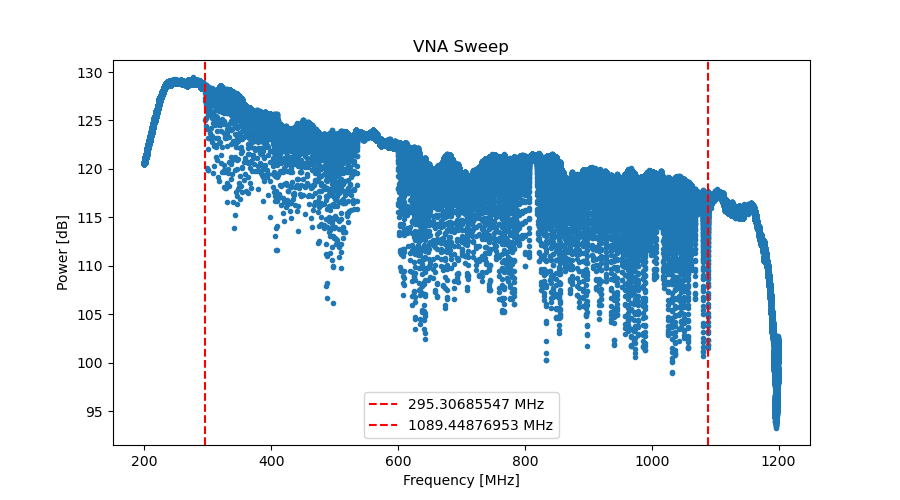

<IPython.core.display.Javascript object>


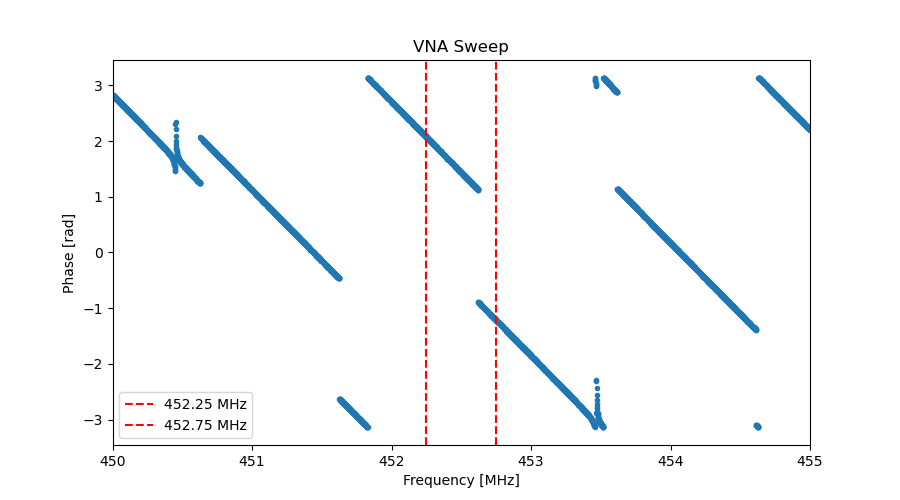

In [24]:
# VNA sweep

# path = "tmp"
path = "twoOctaveReadout_files"
f, Z = np.load(os.path.join(path, f"s21_vna_{cut}.npy"))
f = f.real

mag = np.abs(Z)
phase = np.angle(Z)
# phase = np.unwrap(phase)

plt.figure(1, figsize=(9, 5))
plt.title("VNA Sweep")
plt.plot(f/1e6, db(mag), '.')
plt.xlabel("Frequency [MHz]")
plt.ylabel("Power [dB]")
plt.axvline(x=295.30685547, color='red', linestyle='--', label='295.30685547 MHz')
plt.axvline(x=1089.44876953, color='red', linestyle='--', label='1089.44876953 MHz')
# plt.ylim(80, 130)
# plt.xlim(158, 161)
# plt.xlim(3.755, 3.760)
plt.legend()
plt.show()

plt.figure(2, figsize=(9, 5))
plt.title("VNA Sweep")
plt.plot(f/1e6, phase, '.')
plt.xlabel("Frequency [MHz]")
plt.ylabel("Phase [rad]")
plt.axvline(x=452.25, color='red', linestyle='--', label='452.25 MHz')
plt.axvline(x=452.25+0.5, color='red', linestyle='--', label='452.75 MHz')
# plt.axhline(y=0.3121, color='grey', linestyle='--', label='0.3121 rad')
plt.xlim(450, 455)
# plt.ylim(-200, 200)
plt.legend()
plt.show()

In [25]:
# f_res_vna

path = "twoOctaveReadout_files"

f_res_vna = np.load(os.path.join(path, f"f_res_vna_{cut}.npy"))
print("num of det found by VNA sweep:", f_res_vna.shape)
print("det freqs from VNA sweep [MHz]:\n", f_res_vna.real/1e6)

num of det found by VNA sweep: (271,)
det freqs from VNA sweep [MHz]:
 [ 295.24011719  296.79552734  297.41908203  298.31556641  299.58908203
  300.66287109  302.63066406  303.81951172  304.71699219  306.22507812
  308.6725      309.81302734  310.98742187  312.43724609  313.24957031
  313.85220703  315.35232422  316.86689453  319.39748047  320.40253906
  321.13267578  322.91519531  325.233125    326.05689453  327.28507812
  329.07257813  329.71107422  330.28035156  332.37712891  334.08892578
  336.18023437  337.59966797  339.27162109  341.6         342.69869141
  344.44933594  346.17009766  346.77572266  347.41720703  349.81630859
  351.26912109  352.21392578  353.80767578  354.56769531  356.25359375
  359.24736328  360.70814453  362.55839844  363.70490234  364.94404297
  367.08267578  368.66945313  369.49720703  371.23091797  372.58212891
  374.24412109  377.00580078  379.029375    382.14167969  383.32304687
  385.72712891  387.21380859  388.33441406  389.47544922  390.78332031
  392.

<IPython.core.display.Javascript object>


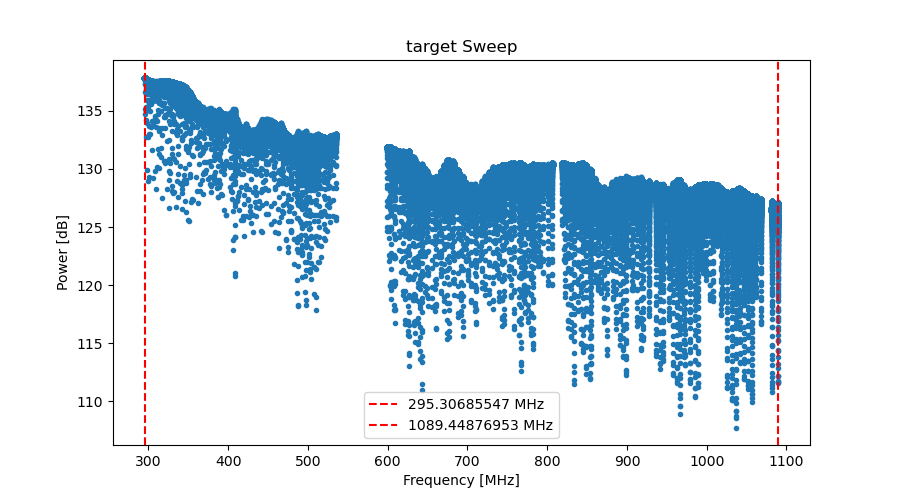

<IPython.core.display.Javascript object>


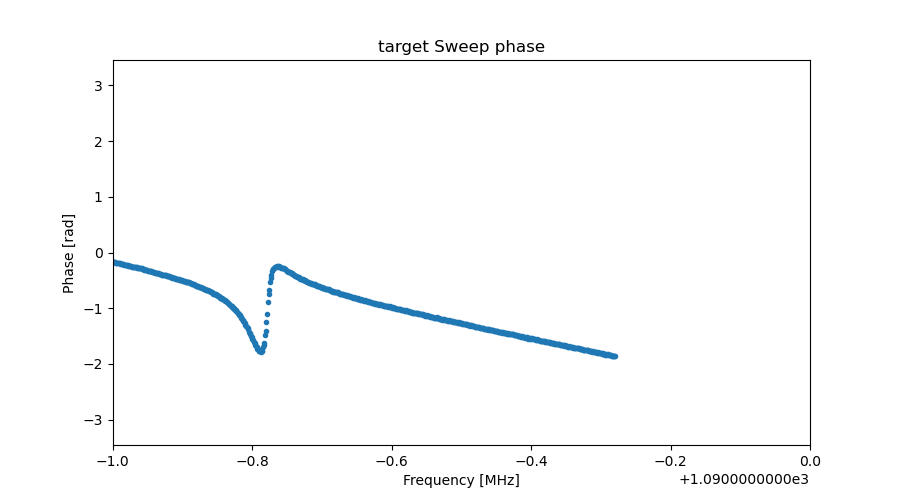

In [26]:
# Targ sweep

# path = "tmp"
path = "twoOctaveReadout_files"
f, Z = np.load(os.path.join(path, f"s21_targ_{cut}.npy"))
f = f.real

mag = np.abs(Z)
phase = np.angle(Z)
# phase = np.unwrap(phase)

plt.figure(3, figsize=(9, 5))
plt.title("target Sweep")
plt.plot(f/1e6, db(mag), '.')
plt.xlabel("Frequency [MHz]")
plt.ylabel("Power [dB]")
# plt.axvline(x=159.25e6, color='red', linestyle='--', label='159.25 MHz')
# plt.axvline(x=159.75e6, color='red', linestyle='--', label='159.75 MHz')
# plt.ylim(80, 130)
# plt.ylim(110, 160)
# plt.xlim(158e6, 161e6)
plt.axvline(x=295.30685547, color='red', linestyle='--', label='295.30685547 MHz')
plt.axvline(x=1089.44876953, color='red', linestyle='--', label='1089.44876953 MHz')
plt.legend()
plt.show()

plt.figure(4, figsize=(9, 5))
plt.title("target Sweep phase")
plt.plot(f/1e6, phase, '.')
plt.xlabel("Frequency [MHz]")
plt.ylabel("Phase [rad]")
# plt.axvline(x=159.25e6, color='red', linestyle='--', label='159.25 MHz')
# plt.axvline(x=159.75e6, color='red', linestyle='--', label='159.75 MHz')
# plt.axhline(y=0.3121, color='grey', linestyle='--', label='0.3121 rad')
plt.xlim(1089, 1090)
# plt.ylim(-200, 200)
# plt.legend()
plt.show()

In [27]:
# path = "tmp"
# path = "twoOctaveReadout_files"
# f, Z = np.load(os.path.join(path, f"s21_targ_{cut}.npy"))
# f = f.real

# mag = np.abs(Z)
# phase = np.angle(Z)
# # phase = np.unwrap(phase)

# plt.figure(100, figsize=(9, 5))
# plt.title("target Sweep")
# plt.plot(f, db(mag) + 20, '.')
# plt.xlabel("Frequency [Hz]")
# plt.ylabel("Power [dB]")
# # plt.axvline(x=159.25e6, color='red', linestyle='--', label='159.25 MHz')
# # plt.axvline(x=159.75e6, color='red', linestyle='--', label='159.75 MHz')
# # plt.ylim(80, 130)
# plt.ylim(110, 160)
# # plt.xlim(158e6, 161e6)
# # plt.legend()
# plt.show()

In [28]:
# f_res_targ

path = "twoOctaveReadout_files"
f_res_targ = np.load(os.path.join(path, f"f_res_targ_{cut}.npy"))
print("num of det found by Targ sweep:", f_res_targ.shape)
print("det freqs from Targ sweep [MHz]:\n", f_res_targ.real/1e6)

num of det found by Targ sweep: (271,)
det freqs from Targ sweep [MHz]:
 [ 295.23923438  296.79441016  297.41894531  298.31442969  299.58786719
  300.66208594  302.62985938  303.81933594  304.71679688  306.22409766
  308.67236328  309.81298828  310.98730469  312.43701172  313.24951172
  313.85305078  315.35253906  316.86669922  319.39746094  320.40234375
  321.1328125   322.91503906  325.23291016  326.05712891  327.28515625
  329.07175391  329.7109375   330.28027344  332.37695312  334.08886719
  336.18017578  337.59960938  339.27148438  341.60009766  342.69773047
  344.44921875  346.16992188  346.77587891  347.41699219  349.81640625
  351.26904297  352.21486719  353.80761719  354.56787109  356.25341797
  359.24755859  360.70800781  362.55859375  364.11707812  364.94284766
  367.08151953  368.66743359  369.49607031  371.22995703  372.58003125
  374.24114063  377.00385937  379.02729687  382.13960156  383.32024219
  385.72505078  387.21186719  388.33147266  389.47358594  390.78120312
  39

result.shape =  (8, 1024)
magnitude range of result: 
79345.94181291977 <-> 5514403.289729164
SNR.shape =  (1024,)
SNR in each bin: 
 [58.43443433 60.59457897 52.98662877 54.84847001 59.8699089  61.08987414
 59.58934478 55.02986528 56.21554708 57.18695875 62.32512828 56.62998432
 59.21783888 59.71883312 55.67383644 55.0196629  62.10825005 62.34193819
 59.34877937 51.62704889]
Avg SNR = 45.173617878996026 [dBc/Hz]
time stream angle:  1.2949732773616622


<IPython.core.display.Javascript object>


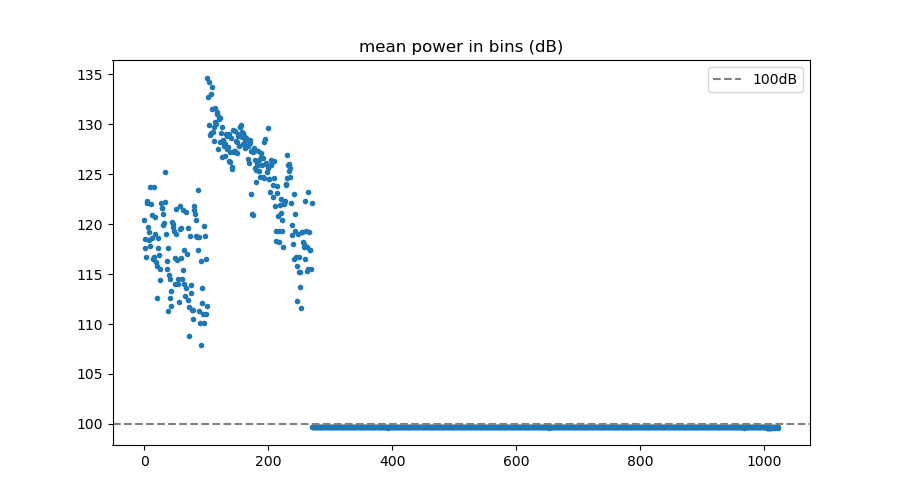

In [29]:
I, Q = getSnapData(cut, 3)
result = (I + 1.j * Q)
result = result.reshape((-1, 1024))

path = "twoOctaveReadout_files"
beat_dphi_map = np.load(os.path.join(path, f"beat_dphi_map_tones_comb_{cut}.npy"))
LUT_x, LUT_y = get_FFT_correction()
FFT_correction = np.interp(beat_dphi_map, LUT_x, LUT_y)[0:1024]
result *= FFT_correction

print("result.shape = ", result.shape)
print("magnitude range of result: ")
print_min_max(result)

result_power = np.abs(result)**2
# print("result_power.T.flatten():\n", result_power.T.flatten()[0:20])

sampling_rate = 1.024e9/(2048*1024)  # Hz
mean_power = np.mean(result_power, axis=0)
variance = np.var(result.real, axis=0) + np.var(result.imag, axis=0)
SNR = mean_power / variance
print("SNR.shape = ", SNR.shape)
SNR_dBcPerHz = 10*np.log10(SNR) + 10*np.log10(sampling_rate)
print("SNR in each bin: \n", SNR_dBcPerHz[0:20])
print(f"Avg SNR = {np.mean(SNR_dBcPerHz)} [dBc/Hz]")

print("time stream angle: ", np.angle(np.mean(result[:, 2])))

# ------------------------------------------------------------------------
plt.figure(5, figsize=(9, 5))
plt.title("mean power in bins (dB)")
plt.plot(10*np.log10(mean_power[0:1024]), '.', alpha=1)
# for x in bin_map:
#     plt.axvline(x=x, color='grey', linestyle='-', alpha=0.5)
# plt.axvline(x=530, color='red', linestyle='--', label='bin=530')
# plt.axvline(x=500, color='grey', linestyle='--', label='bin=500')
plt.axhline(y=100, color='grey', linestyle='--', label='100dB')
# plt.xlim(0, 250)
# plt.ylim(70, 125)
plt.legend()
plt.show()

<IPython.core.display.Javascript object>


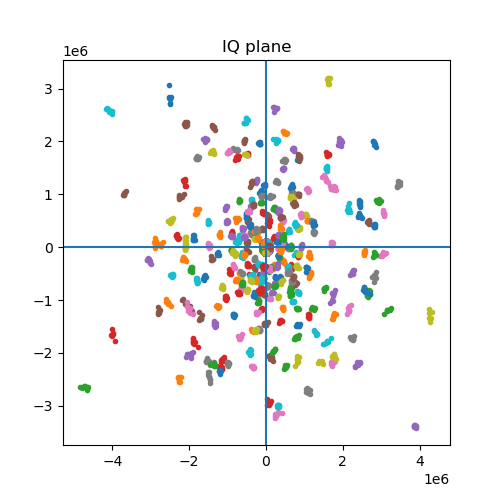

In [30]:
# Visualize time stream on the IQ plane
plt.figure(1000, figsize=(5,5))
plt.title("IQ plane")
for i in range(1024):
    plt.plot(result[:, i].real, result[:, i].imag, ".")
plt.axvline(x=0)
plt.axhline(y=0)
# plt.xlim(-150000, 150000)
# plt.ylim(-150000, 150000)
plt.show()

PSB output range:
18.35755975068582 <-> 12382.602715099923
ADC output range:
37.94733192202055 <-> 13732.13610477263
ADC_out.shape =  (8192,)


DAC:
1.0 <-> 11593.0
0.0 <-> 11675.0
ADC:
0.0 <-> 11302.0
0.0 <-> 13361.0


<IPython.core.display.Javascript object>


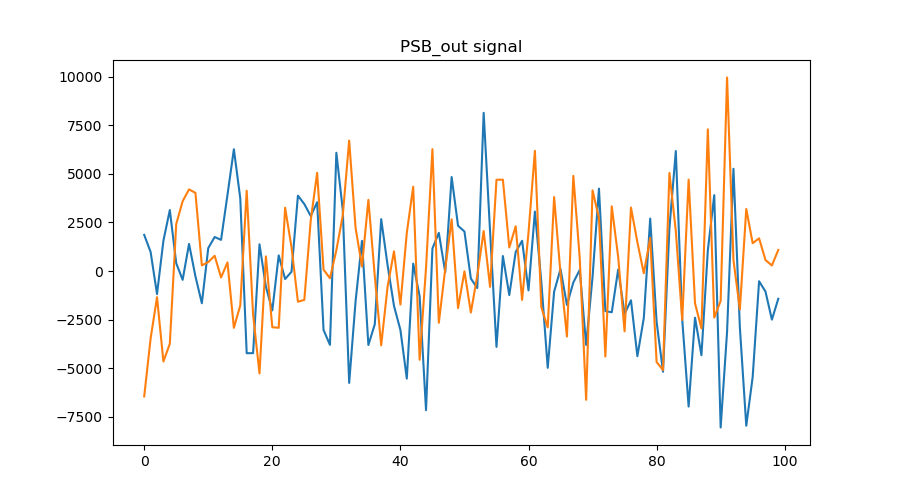

<IPython.core.display.Javascript object>


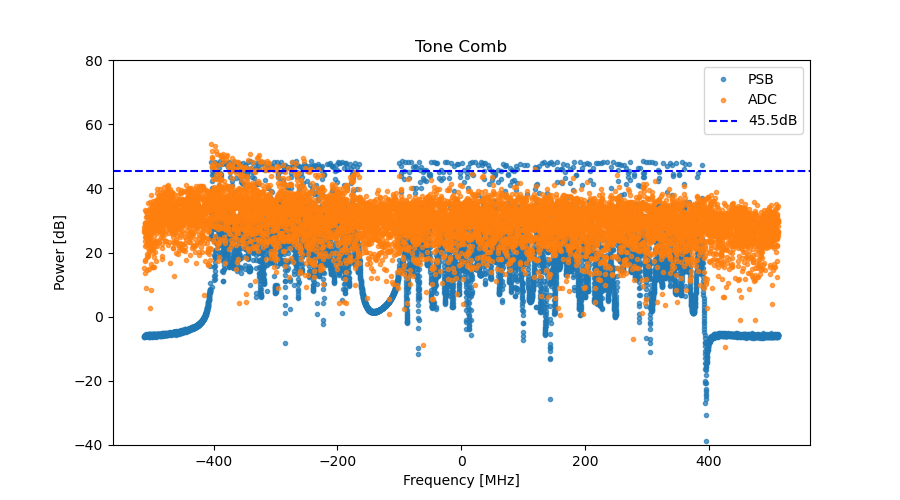

In [31]:
I, Q = getSnapData(cut, 1)
PSB_out = (I + 1.j * Q)
I, Q = getSnapData(cut, 0)
ADC_out = (I + 1.j * Q)
print("PSB output range:")
print_min_max(PSB_out)
print("ADC output range:")
print_min_max(ADC_out)
print("ADC_out.shape = ", ADC_out.shape)

print('\n')
print("DAC:")
print_min_max(PSB_out.real)
print_min_max(PSB_out.imag)
print("ADC:")
print_min_max(ADC_out.real)
print_min_max(ADC_out.imag)

# ------------------------------------------------------------------------------------------------------------
plt.figure(6, figsize=(9, 5))
plt.title("PSB_out signal")
plt.plot(PSB_out.real[600:700])
plt.plot(PSB_out.imag[600:700])
plt.show()

# ------------------------------------------------------------------------------------------------------------
fs=1.024e9
fft_length = 8192 * 1
ADC_out_scale = 2**0

figComb = plt.figure(7, figsize=(9, 5))
plt.title(f"Tone Comb")
xf = np.fft.fftfreq(fft_length, 1./fs)
plt.plot(xf/1e6, db(np.fft.fft(PSB_out, fft_length)/fft_length), '.', label='PSB', alpha=0.7)
plt.plot(xf/1e6, db(np.fft.fft(ADC_out*ADC_out_scale, fft_length)/fft_length), '.', label='ADC', alpha=0.7) # , '.'
plt.xlabel("Frequency [MHz]")
plt.ylabel("Power [dB]")

# plt.axhline(y=60, color='blue', linestyle='--', label='60dB')
# plt.axhline(y=41, color='orange', linestyle='--', label='41dB')
# plt.axhline(y=60+tone_power, color='blue', linestyle='--', label=f'{60+tone_power}dB')
plt.axhline(y=45.5+tone_power, color='blue', linestyle='--', label=f'{45.5+tone_power}dB')

# plt.axhline(y=22-6, color='orange', linestyle='--', label='22 dB')
# plt.axhline(y=43.7-6, color='blue', linestyle='--', label='43.7 dB')
# plt.axhline(y=-12, color='orange', linestyle='--', label='-12 dB')
# plt.axhline(y=-19.9, color='blue', linestyle='--', label='-19.9 dB')

# plt.axvline(x=-240e6, color='red', linestyle='--')
# plt.axvline(x=-250e6, color='red', linestyle='--')

# plt.axvline(x=(test_bin-1)*500e3-250e3)
# plt.axvline(x=(test_bin-1)*500e3, linestyle='--')
# plt.axvline(x=test_bin*500e3-250e3, color='green')
# plt.axvline(x=test_bin*500e3, linestyle='--', color='green')
# plt.axvline(x=test_bin*500e3+250e3, color='green')
# plt.axvline(x=(test_bin+1)*500e3, linestyle='--')
# plt.axvline(x=(test_bin+1)*500e3+250e3)
# plt.xlim(test_bin*500e3-250e3-500e3*5, test_bin*500e3+250e3+500e3*5)

# plt.xlim(-250e3, 250e3)
plt.ylim(-40, 80)
plt.legend()
plt.show()